## Setting Up a Markov Chain

Markov chains are used in MCMC methods to ensure that Monte Carlo samples are being drawn from the correct distributions. Markov Chains work by setting a target distribution (the fully conditional distribution) and setting up transition probabilities to move from the current state in the chain to the next state.       

If the transition probabilities are set up correctly the Markov chain will always "burn in" to the correct target distribution for Monte Carlo sampling.


## Setting Up a Markov Chain

Here is a simple example of how a Markov Chain works. In this example we want to know the probability that any given day will be sunny or cloudy. To do this we need to set up a matrix of transition probabilities of going from 1 state (sunny or cloudy) to another state (sunny of cloudy):

$$\begin{bmatrix}
p(sunny-to-sunny)&p(sunny-to-cloudy) \\
p(cloudy-to-sunny)&p(cloudy-to-cloudy) \\
\end{bmatrix}$$

To start lets set this transition matrix to:
$$\begin{bmatrix}
p(sunny-to-sunny)=.4&p(sunny-to-cloudy)=.6 \\
p(cloudy-to-sunny)=.2&p(cloudy-to-cloudy)=.8 \\
\end{bmatrix}$$



In [1]:
#setting the transition probabilities
pi=c(.4,.2,.6,.8)
dim(pi)=c(2,2)
pi

0.4,0.6
0.2,0.8


Based on the transition probabilities what can we say about the frequency of sunny days and cloudy days?

## Burn In

With a Markov Chain we start with some selected starting point and continuously sample until the chain has reach the stationary or target distribution. We will start the chain with the probability of a sunny day equal to 1.

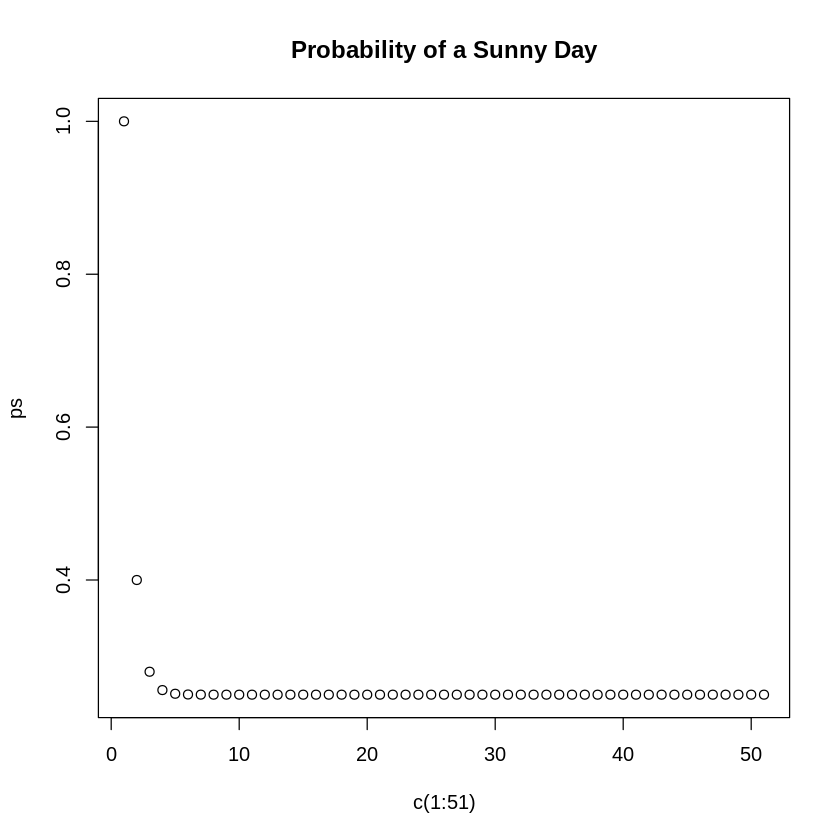

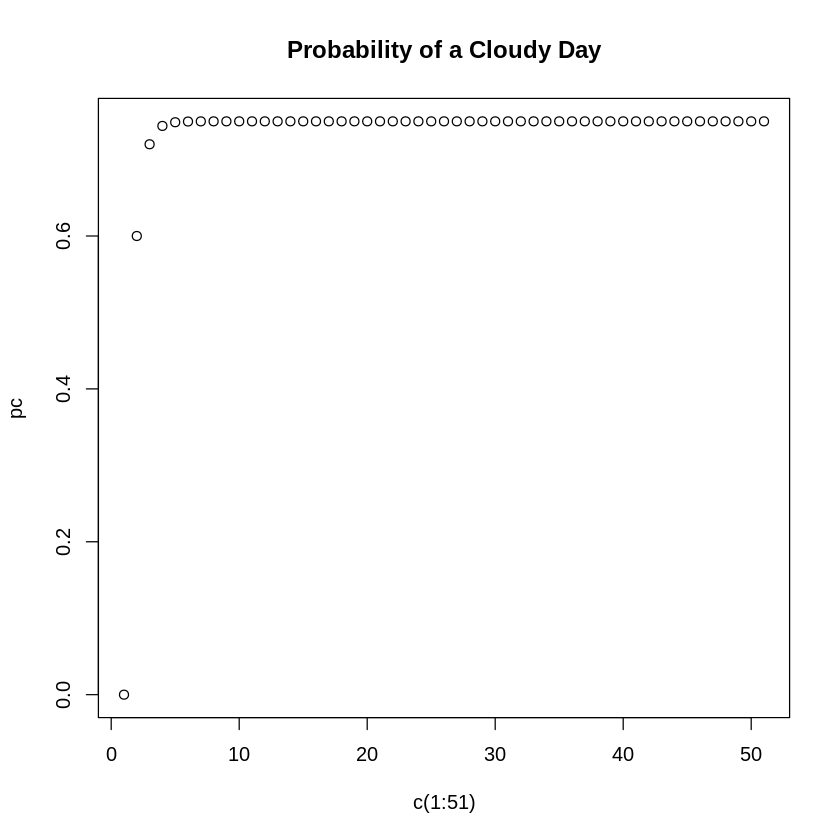

In [2]:
# initiate the probability of sunny and cloudy
p=c(1,0)

# the get to the target distribution we will continue to multiply p%*%pi
# vector to save the updated probabilities of it being sunny
ps=rep(0,51)
ps[1]=1
# vector to save the updated probabilities of it being cloudy
pc=rep(0,51)
pc[1]=0
for(i in c(1:50)){
  p=p%*%pi
  ps[(i+1)]=p[1]
  pc[(i+1)]=p[2]
}

plot(c(1:51),ps,main="Probability of a Sunny Day")
plot(c(1:51),pc,main="Probability of a Cloudy Day")

## What happens if the transition prbabilities are specified incorrectly?

To test this we will set up a new transition probability matrix as:

$$\begin{bmatrix}
p(sunny-to-sunny)=.4&p(sunny-to-cloudy)=.7 \\
p(cloudy-to-sunny)=.2&p(cloudy-to-cloudy)=.7 \\
\end{bmatrix}$$

In [3]:
#setting the transition probabilities
pi=c(.4,.2,.7,.7)
dim(pi)=c(2,2)
pi

0.4,0.7
0.2,0.7


# What is problematic about this transition matrix?

## Setting up a Markov Chain with the new transition probabilities

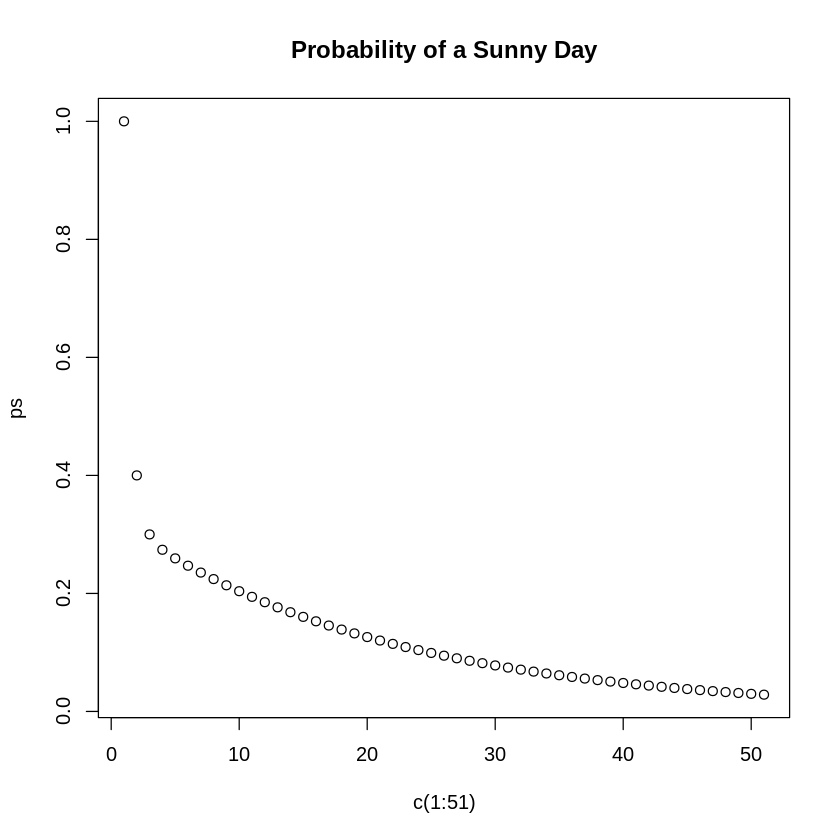

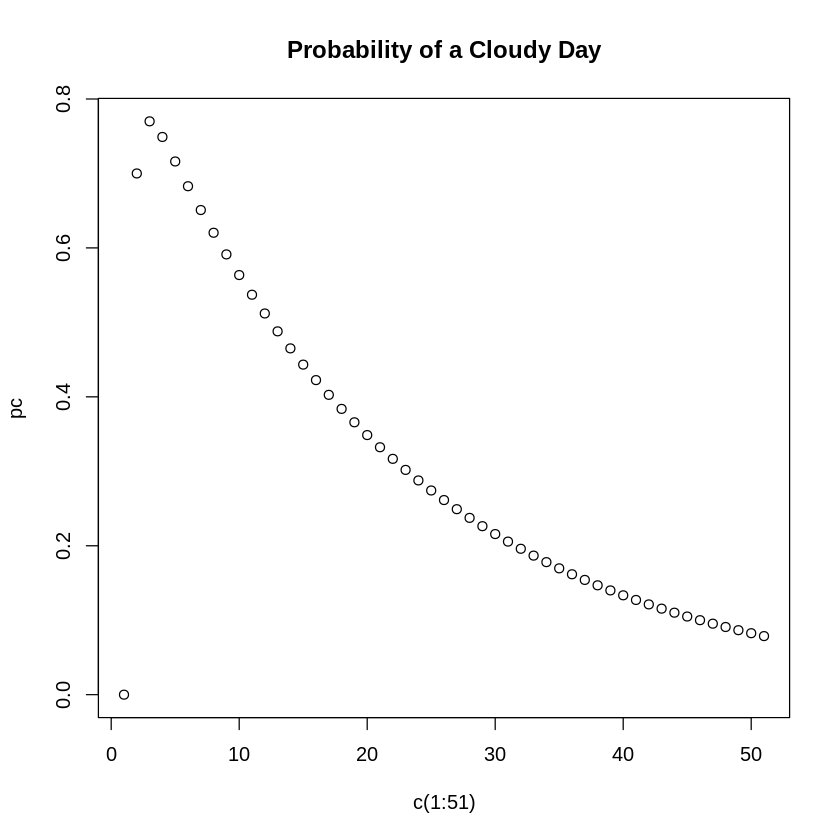

In [4]:
# initiate the probability of sunny and cloudy
p=c(1,0)

# the get to the target distribution we will continue to multiply p%*%pi
# vector to save the updated probabilities of it being sunny
ps=rep(0,51)
ps[1]=1
# vector to save the updated probabilities of it being cloudy
pc=rep(0,51)
pc[1]=0
for(i in c(1:50)){
  p=p%*%pi
  ps[(i+1)]=p[1]
  pc[(i+1)]=p[2]
}

plot(c(1:51),ps,main="Probability of a Sunny Day")
plot(c(1:51),pc,main="Probability of a Cloudy Day")